# SENTINEL-WM | Phase 6a - Explainability

Three complementary attributions on the trained world model:
**SHAP** (KernelExplainer / finite-diff fallback), **temporal attention
saliency** (which past window drove the call), **gradient x input**
(per feature x window). Baseline SHAP too.

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import numpy as np, matplotlib.pyplot as plt
from sentinel_wm import config as C, explain as EX
device = C.resolve_device('auto')

C:\Users\chall\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.1  Global attribution - world model vs baselines

  0%|          | 0/64 [00:00<?, ?it/s]

  2%|▏         | 1/64 [00:00<00:11,  5.63it/s]

  3%|▎         | 2/64 [00:00<00:10,  6.20it/s]

  5%|▍         | 3/64 [00:00<00:09,  6.50it/s]

  6%|▋         | 4/64 [00:00<00:08,  6.74it/s]

...

 97%|█████████▋| 62/64 [00:08<00:00,  7.05it/s]

 98%|█████████▊| 63/64 [00:09<00:00,  6.87it/s]

100%|██████████| 64/64 [00:09<00:00,  6.95it/s]

100%|██████████| 64/64 [00:09<00:00,  6.97it/s]

[explain] shap_installed=True
[explain] world-model top features:
    payload_kurt_mean          0.0841
    ttl_mean                   0.0660
    syn_rate                   0.0543
    window_index_in_day        0.0526
    fwd_bwd_ratio              0.0434
    payload_skew_mean          0.0393
    failed_conn_ratio          0.0375
    psh_rate                   0.0354
[explain] -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\reports\explainability.json
SHAP installed: True


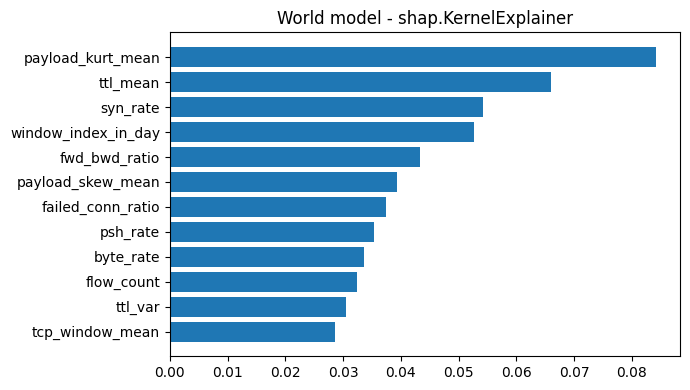

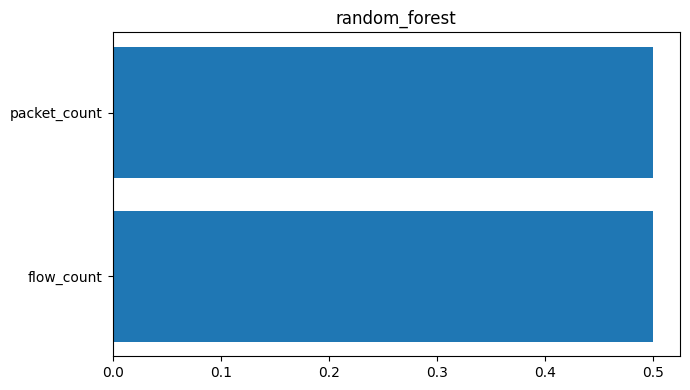

In [3]:
rep = EX.run_all(device)
print('SHAP installed:', rep['has_shap'])
def bar(d, key, title):
    t = d['top_features'][:12]
    plt.figure(figsize=(7,4))
    plt.barh([x['feature'] for x in t][::-1], [x[key] for x in t][::-1])
    plt.title(title); plt.tight_layout(); plt.show()
bar(rep['world_model_shap'], 'mean_abs_shap', 'World model - '+rep['world_model_shap']['method'])
bar(rep['baseline_rf_shap'], 'importance', 'random_forest')

## 4.2  Per-anchor - attention + gradient saliency for one attack window

In [4]:
import torch, json
from sentinel_wm.sequences import load_sequences
from sentinel_wm.models import build_model
seq = load_sequences(); te = np.where(seq['split']=='test')[0]
i = int(te[np.argmax(seq['y_atk'][te].max(1))])
ck = torch.load(C.WORLD_MODEL_PT, map_location=device, weights_only=False)
cfg = C.CONFIG; cfg.sequence.horizon = ck['sequence']['K']
m = build_model(ck['config']['n_features'], cfg).to(device); m.load_state_dict(ck['state_dict']); m.eval()
gi = EX.gradient_x_input(m, seq['X'][i], seq['dt'][i], list(seq['feature_names']), device)
att = EX.attention_saliency(m, seq['X'][i], seq['dt'][i], device)
print('attention over the 10 history windows:', np.round(att,3))
print('top features:', [t['feature'] for t in gi['top_features'][:6]])

attention over the 10 history windows: [0.321 0.133 0.104 0.096 0.115 0.089 0.067 0.045 0.026 0.003]
top features: ['psh_rate', 'window_index_in_day', 'flow_count', 'byte_rate', 'ack_rate', 'syn_rate']


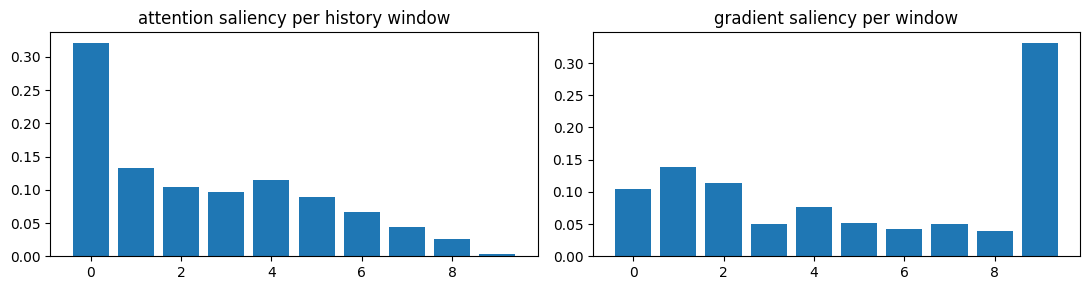

In [5]:
fig,ax = plt.subplots(1,2,figsize=(11,3))
ax[0].bar(range(len(att)), att); ax[0].set_title('attention saliency per history window')
ax[1].bar(range(len(gi['per_window'])), gi['per_window']); ax[1].set_title('gradient saliency per window')
plt.tight_layout()

Report JSON: `../../runs/explainability/explainability.json`.